https://archive.ics.uci.edu/dataset/967/phiusiil+phishing+url+dataset
PhiUSIIL Phishing URL (Website)

**Final Project**
Due May 7 by 11pm Points 100 Submitting a file upload File Types pdf Available until May 7 at 11:15pm
Up to this point, we have learned and discussed several machine learning algorithms. Now, it's time to put that knowledge into practice by applying these techniques to a problem of your own choosing. This could be any topic that sparks your interest!

To begin your project, consider areas you're passionate about, and look for publicly accessible datasets related to those interests.

You can explore the datasets/environments in Resources page under the Start Here module.

NOTE: The data or problem should be sufficiently complex, requiring a minimum of approximately 10,000 samples and at least 5 features.  In Data section, you should explicitly mention the size of data. 


The project requires a comprehensive machine learning pipeline, including: data exploration and analysis with appropriate visualizations; preprocessing (with explanations if not needed); selection of machine learning algorithms (at least two ML algorithms) with a rationale for each choice; and detailed observation and analysis of results, discussing whether the model performs as expected and identifying potential improvements.

* The bold face items above are key factors in determining your project grade.

**Submission**
**You are preparing a project report (pdf).  The recommended structure of the report contains:**

Cover page
- title
- name
  
Introduction

Data
- Introduce the data
- perform basic (visual) analysis
- Preprocessing
  
Methods
- details of your ML algorithms (at least two algorithms/models)
  
Results
- Explain detailed set up to solve the problem
- test your methods and show the results
- Discuss observation and analyze them
  
Conclusions
- conclude your work
- don't forget to mention what you have learned!
  
References
- It is important to cite others' work.
  
Acknowledgement
- if you use online resources and AI for your project, properly state them here how you use them. Check my slides for example acknowledgement.

Source Code
- Provide a GitHub link (make sure to be publicly accessible for grading)
  
**Use MLA style to cite and reference others work!**

# Using Machine Learning to Recongize Phishing URLs

#### 1    Introduction
This is the final individual report for ITSC 3156.  My project's goal is to utilize machine learning to train a model to help individuals to recognize fake URL to avoid phishing schemes. The code for the project is located on github:  https://github.com/


#### 1.1  Problem Statement
Phishing URL websites pose a significant threat to individuals, as they can lead to wasted time, financial fraud, and even misdirected career opportunities. The increasing prevalence of phishing URLs across various platforms underscores the urgent need for effective detection methods to safeguard users.


#### 1.2  Motivation and Challenges
The motivation for our study is to assist individuals in making better decisions about the credibility of URLs by developing a binary classification model.  The authors collected phishing URLs and email data from the last fifteen years from Anti-Phishing Working Group (APWG)
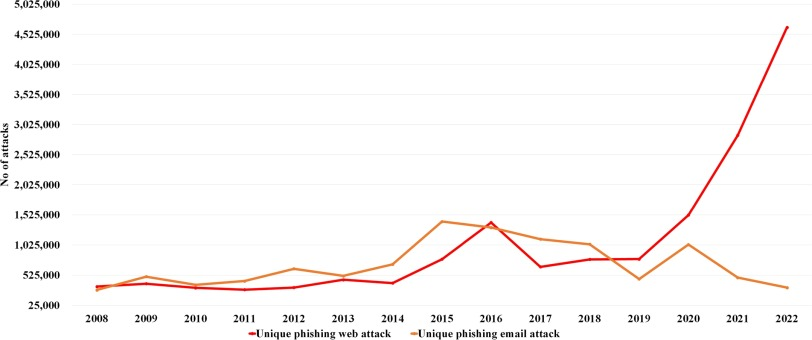

Figure 1  illustrates a significantlyincrease in phishing attack on URLs since 2019 in the pandemic, coinciding with pandemic which forced everyone to pivot from a physical to a more digital or online presenence.  (Nurhas et al., 2022).   This shift lead to an significant increase of sophisticated cyberattacks including URL phishing (Shih et al., 2023). "Cybercriminals often use subdomain spoofing techniques by creating a subdomain resembling a legitimate website to convince users they are accessing a legitimate website" (Maroofi et al., 2021). 

The primary challenges in this study include constructing a robust model that does not rely on token-based analysis, and large-language models. Instead, we applied on simple classification methods to determine whether similar results could be achived. 

#### 1.3  Concise Summary
In our study, the PhiUSIIL Phishing URL dataset contains 235,795 URL listings, of which 100,945 are classified as phishing URLs. The dataset includes fifty-four features related to each URL, such as filename, URL length, and domain, which were extracted from the webpage source code by the author.

We evaluated the final dataset using three machine learning algorithms: Neural Network, Random Forest with PCA, and Logistic Regression. The best performance was achieved with the Neural Network model.

Our project analyzes the strengths and weaknesses of each algorithm, providing guidance for determining whether a website is legitimate or not.


SECTION CHECKED 5/4/2025

In [1]:
#pip install xgboost scikit-learn

In [2]:
#pip install imblearn
import imblearn

#### 2    Data / environment

In [3]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import sklearn
import xgboost as xgb

from typing import List, Dict, Tuple, Callable
import os
import gc
import traceback
import warnings
from pdb import set_trace

from sklearn.metrics import root_mean_squared_error as rmse
from sklearn.metrics import mean_squared_error as mse

In [4]:
phishing = pd.read_csv("PhiUSIIL_Phishing_URL_Dataset.csv")
phishing.head(4)

,FILENAME,URL,URLLength,Domain,DomainLength,IsDomainIP,TLD,URLSimilarityIndex,CharContinuationRate,TLDLegitimateProb,...,Pay,Crypto,HasCopyrightInfo,NoOfImage,NoOfCSS,NoOfJS,NoOfSelfRef,NoOfEmptyRef,NoOfExternalRef,label
0,521848.txt,https://www.southbankmosaics.com,31,www.southbankmosaics.com,24,0,com,100.0,1.000000,0.522907,...,0,0,1,34,20,28,119,0,124,1
1,31372.txt,https://www.uni-mainz.de,23,www.uni-mainz.de,16,0,de,100.0,0.666667,0.032650,...,0,0,1,50,9,8,39,0,217,1
2,597387.txt,https://www.voicefmradio.co.uk,29,www.voicefmradio.co.uk,22,0,uk,100.0,0.866667,0.028555,...,0,0,1,10,2,7,42,2,5,1
3,554095.txt,https://www.sfnmjournal.com,26,www.sfnmjournal.com,19,0,com,100.0,1.000000,0.522907,...,1,1,1,3,27,15,22,1,31,1


In [5]:
phishing.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 235795 entries, 0 to 235794
Data columns (total 56 columns):
 #   Column                      Non-Null Count   Dtype  
---  ------                      --------------   -----  
 0   FILENAME                    235795 non-null  object 
 1   URL                         235795 non-null  object 
 2   URLLength                   235795 non-null  int64  
 3   Domain                      235795 non-null  object 
 4   DomainLength                235795 non-null  int64  
 5   IsDomainIP                  235795 non-null  int64  
 6   TLD                         235795 non-null  object 
 7   URLSimilarityIndex          235795 non-null  float64
 8   CharContinuationRate        235795 non-null  float64
 9   TLDLegitimateProb           235795 non-null  float64
 10  URLCharProb                 235795 non-null  float64
 11  TLDLength                   235795 non-null  int64  
 12  NoOfSubDomain               235795 non-null  int64  
 13  HasObfuscation

In [6]:
phishing.isnull().sum()

FILENAME                      0
URL                           0
URLLength                     0
Domain                        0
DomainLength                  0
IsDomainIP                    0
TLD                           0
URLSimilarityIndex            0
CharContinuationRate          0
TLDLegitimateProb             0
URLCharProb                   0
TLDLength                     0
NoOfSubDomain                 0
HasObfuscation                0
NoOfObfuscatedChar            0
ObfuscationRatio              0
NoOfLettersInURL              0
LetterRatioInURL              0
NoOfDegitsInURL               0
DegitRatioInURL               0
NoOfEqualsInURL               0
NoOfQMarkInURL                0
NoOfAmpersandInURL            0
NoOfOtherSpecialCharsInURL    0
SpacialCharRatioInURL         0
IsHTTPS                       0
LineOfCode                    0
LargestLineLength             0
HasTitle                      0
Title                         0
DomainTitleMatchScore         0
URLTitle

In [7]:
phishing_clean = phishing.drop(["FILENAME", 'URL', 'URLLength', 'Domain', 'Title', 'TLD'], axis = 1)
phishing_clean.head(4)

,DomainLength,IsDomainIP,URLSimilarityIndex,CharContinuationRate,TLDLegitimateProb,URLCharProb,TLDLength,NoOfSubDomain,HasObfuscation,NoOfObfuscatedChar,...,Pay,Crypto,HasCopyrightInfo,NoOfImage,NoOfCSS,NoOfJS,NoOfSelfRef,NoOfEmptyRef,NoOfExternalRef,label
0,24,0,100.0,1.000000,0.522907,0.061933,3,1,0,0,...,0,0,1,34,20,28,119,0,124,1
1,16,0,100.0,0.666667,0.032650,0.050207,2,1,0,0,...,0,0,1,50,9,8,39,0,217,1
2,22,0,100.0,0.866667,0.028555,0.064129,2,2,0,0,...,0,0,1,10,2,7,42,2,5,1
3,19,0,100.0,1.000000,0.522907,0.057606,3,1,0,0,...,1,1,1,3,27,15,22,1,31,1


#### 2     Data

This dataset was downloaded from UC Irvine Machine Learning Repository. The PhiUSIIL Phishing URL dataset contains 235,795 URLs of which 100,945 are phishing URLs. The dataset includes fifty-four features related to an URL such as filename, URLLength, and domain which were extracted from the webpage source code by the author.  The data is tabular and contains real numbers, categorical values and integers.   The authors created PhoUSIIL, a Phishing URL detection framework based on similarity index, which extracted the URL features from existing information to construct the phishing URL dataset we are using. This dataset was used on PhiUSIIL to improve the accuracy to 99.24% when using on fully incremental training approach. (Arvind Prasad∗, Shalini Chandra)


#### 2.1    Data visualization

We began data exploration and visualization by reviewing the balance of legitimate verses phishing URLS.  Originally, the dataset had a moderate imbalance as displayed in Figure 2.  After undersampling, the dataset is balanced with 100,945 URLs in each group. Figure 3.

Text(0, 0.5, 'Frequency')

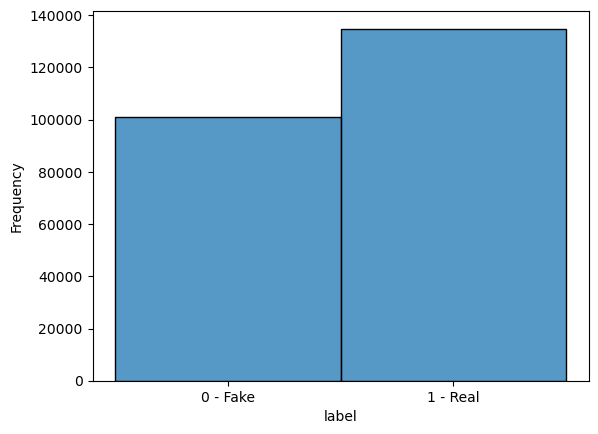

In [8]:
sns.histplot(phishing_clean["label"], bins=[-0.5,0.5,1.5], kde=False)
plt.xticks(ticks=[0,1], labels=['0 - Fake', '1 - Real'])
plt.ylabel('Frequency')

Original class distribution: Counter({np.int64(1): 134850, np.int64(0): 100945})
Resampled class distribution: Counter({np.int64(0): 100945, np.int64(1): 100945})


Text(0, 0.5, 'Frequency')

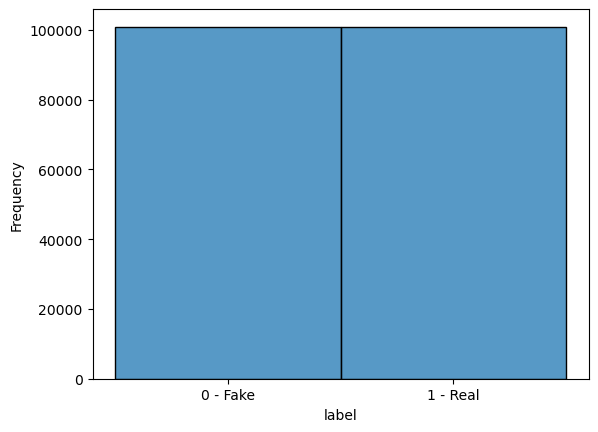

In [9]:

# undersampling majority
# https://imbalanced-learn.org/stable/under_sampling.html
# https://imbalanced-learn.org/stable/references/generated/imblearn.under_sampling.RandomUnderSampler.html#imblearn.under_sampling.RandomUnderSampler

from imblearn.under_sampling import RandomUnderSampler
from collections import Counter

X = phishing_clean.drop('label', axis=1).values
y = phishing_clean['label'].values

print("Original class distribution:", Counter(y))

# Initialize undersampler
undersampler = RandomUnderSampler(sampling_strategy=1.0, random_state=42)

# Apply undersampling
X_resampled, y_resampled = undersampler.fit_resample(X, y)

print("Resampled class distribution:", Counter(y_resampled))

resampled_df = pd.DataFrame(X_resampled, columns=phishing_clean.drop('label', axis=1).columns)
resampled_df["label"] = y_resampled  # Add the label column

sns.histplot(resampled_df["label"], bins=[-0.5,0.5,1.5], kde=False)
plt.xticks(ticks=[0,1], labels=['0 - Fake', '1 - Real'])
plt.ylabel('Frequency')

In [10]:
# sns.pairplot(phishing_clean)

In [11]:
# https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.DataFrame.corr.html
phishing_clean.corr()

,DomainLength,IsDomainIP,URLSimilarityIndex,CharContinuationRate,TLDLegitimateProb,URLCharProb,TLDLength,NoOfSubDomain,HasObfuscation,NoOfObfuscatedChar,...,Pay,Crypto,HasCopyrightInfo,NoOfImage,NoOfCSS,NoOfJS,NoOfSelfRef,NoOfEmptyRef,NoOfExternalRef,label
DomainLength,1.000000,-0.041398,-0.420694,-0.577425,0.027209,-0.178104,0.152669,0.399157,0.041643,0.011304,...,-0.065895,-0.034773,-0.196860,-0.083458,-0.017596,-0.102216,-0.096712,-0.031673,-0.070099,-0.283152
IsDomainIP,-0.041398,1.000000,-0.121439,-0.101307,-0.053220,-0.111769,-0.011125,0.084619,0.001239,0.000354,...,-0.013863,-0.005919,-0.022796,-0.016502,-0.004149,-0.023126,-0.018981,-0.006793,-0.015269,-0.060202
URLSimilarityIndex,-0.420694,-0.121439,1.000000,0.572938,0.162042,0.571622,-0.053915,-0.058481,-0.100159,-0.032257,...,0.291542,0.087228,0.613620,0.235728,0.057683,0.315679,0.271590,0.091556,0.221960,0.860358
CharContinuationRate,-0.577425,-0.101307,0.572938,1.000000,0.237221,0.349810,0.051438,-0.482314,-0.036231,-0.004371,...,0.179145,0.059667,0.345566,0.135931,0.027943,0.183900,0.147881,0.049963,0.121745,0.467735
TLDLegitimateProb,0.027209,-0.053220,0.162042,0.237221,1.000000,0.274224,0.386794,-0.250048,-0.016577,0.001207,...,0.111494,0.038673,0.114394,0.053432,0.008296,0.058475,0.028216,0.015252,0.033182,0.097389
URLCharProb,-0.178104,-0.111769,0.571622,0.349810,0.274224,1.000000,0.069818,-0.081576,-0.056108,-0.029030,...,0.162323,0.062187,0.349530,0.128617,0.034470,0.176119,0.144543,0.050855,0.120841,0.469749
TLDLength,0.152669,-0.011125,-0.053915,0.051438,0.386794,0.069818,1.000000,-0.162431,0.000974,0.001902,...,0.023103,0.017689,-0.043484,-0.029074,-0.004249,-0.024109,-0.046451,-0.014442,-0.026486,-0.079159
NoOfSubDomain,0.399157,0.084619,-0.058481,-0.482314,-0.250048,-0.081576,-0.162431,1.000000,0.015902,-0.001477,...,-0.024983,-0.016590,-0.006321,-0.009474,-0.001003,-0.010226,0.003108,0.001702,-0.001538,-0.005955
HasObfuscation,0.041643,0.001239,-0.100159,-0.036231,-0.016577,-0.056108,0.000974,0.015902,1.000000,0.291858,...,-0.009674,-0.002711,-0.014249,-0.012997,-0.002841,-0.015700,-0.016541,-0.004463,-0.013342,-0.052473
NoOfObfuscatedChar,0.011304,0.000354,-0.032257,-0.004371,0.001207,-0.029030,0.001902,-0.001477,0.291858,1.000000,...,0.001481,-0.001472,0.002169,-0.003830,-0.000577,-0.003356,-0.004828,-0.001601,-0.003515,-0.015315


<Axes: >

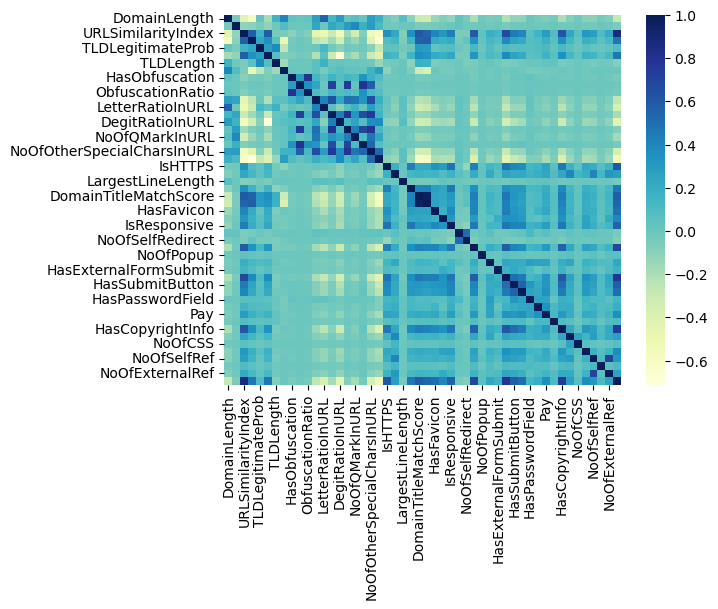

In [12]:
correlations = phishing_clean.corr()
sns.heatmap(correlations, cmap="YlGnBu", annot=False)

In [13]:
#Creating a dictionary of columns with high correlations *** code used from ITCS Data Mining example ****
corr_array = correlations.to_numpy()
high_corr = {}
cols = phishing_clean.columns

for i in range(len(corr_array)):
    temp = list(np.where(corr_array[i] > 0.70)[0])
    if len(temp) < 2:
        continue
    temp.pop(temp.index(i))
    high_corr[cols[i]] = list(cols[temp])

In [14]:
high_corr

{'URLSimilarityIndex': ['label'],
 'HasObfuscation': ['ObfuscationRatio'],
 'NoOfObfuscatedChar': ['NoOfDegitsInURL',
  'NoOfEqualsInURL',
  'NoOfAmpersandInURL'],
 'ObfuscationRatio': ['HasObfuscation'],
 'NoOfDegitsInURL': ['NoOfObfuscatedChar',
  'NoOfEqualsInURL',
  'NoOfOtherSpecialCharsInURL'],
 'NoOfEqualsInURL': ['NoOfObfuscatedChar',
  'NoOfDegitsInURL',
  'NoOfOtherSpecialCharsInURL'],
 'NoOfAmpersandInURL': ['NoOfObfuscatedChar'],
 'NoOfOtherSpecialCharsInURL': ['NoOfDegitsInURL', 'NoOfEqualsInURL'],
 'DomainTitleMatchScore': ['URLTitleMatchScore'],
 'URLTitleMatchScore': ['DomainTitleMatchScore'],
 'HasSocialNet': ['label'],
 'HasCopyrightInfo': ['label'],
 'NoOfSelfRef': ['NoOfExternalRef'],
 'NoOfExternalRef': ['NoOfSelfRef'],
 'label': ['URLSimilarityIndex', 'HasSocialNet', 'HasCopyrightInfo']}

In [15]:
#Get actual correlation value and decide which to drop
for i in high_corr:
    print(i+' correlates with:')
    print(correlations.loc[i][high_corr[i]])
    print('-------------------------------')

URLSimilarityIndex correlates with:
label    0.860358
Name: URLSimilarityIndex, dtype: float64
-------------------------------
HasObfuscation correlates with:
ObfuscationRatio    0.798791
Name: HasObfuscation, dtype: float64
-------------------------------
NoOfObfuscatedChar correlates with:
NoOfDegitsInURL       0.721216
NoOfEqualsInURL       0.754543
NoOfAmpersandInURL    0.786451
Name: NoOfObfuscatedChar, dtype: float64
-------------------------------
ObfuscationRatio correlates with:
HasObfuscation    0.798791
Name: ObfuscationRatio, dtype: float64
-------------------------------
NoOfDegitsInURL correlates with:
NoOfObfuscatedChar            0.721216
NoOfEqualsInURL               0.806024
NoOfOtherSpecialCharsInURL    0.767477
Name: NoOfDegitsInURL, dtype: float64
-------------------------------
NoOfEqualsInURL correlates with:
NoOfObfuscatedChar            0.754543
NoOfDegitsInURL               0.806024
NoOfOtherSpecialCharsInURL    0.784654
Name: NoOfEqualsInURL, dtype: float64
-

- After inspects the high correlating features, I've manually compiled a list of ones to drop
- Also target features were likely derived from existing features.
1.
DomainTitleMatchScore correlates with:
URLTitleMatchScore    0.961008
Name: DomainTitleMatchScore, dtype: float64
2.
HasObfuscation correlates with:
ObfuscationRatio    0.798791
Name: HasObfuscation, dtype: float64


<Axes: >

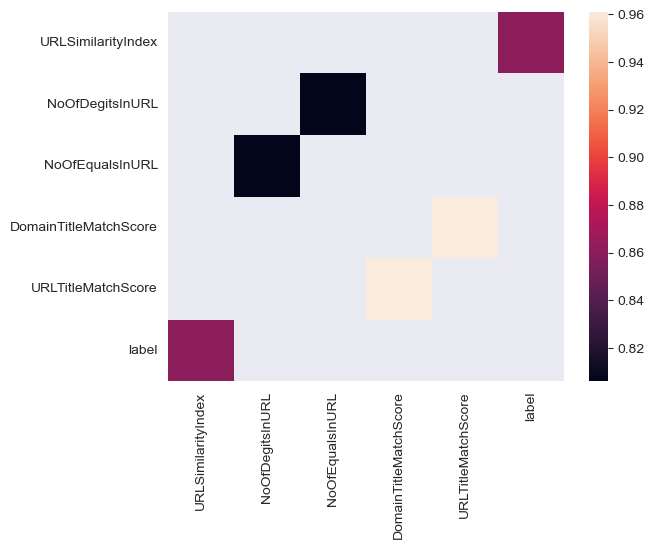

In [16]:
  # again code from Data Mining Fall 2024

# Get those who have a high correlation of .9 or higher
high_corr = correlations[abs(correlations) >= .8]

# This is so we can drop the diagonal since it will be correlation of 1
# Set it to null and we can drop it with the rest 
high_corr.replace(1, np.nan, inplace=True)

# Drop rows and columns where they have no high correlation with anything
high_corr.dropna(how='all', axis=0, inplace=True)
high_corr.dropna(how='all', axis=1, inplace=True)

# Due to the pallet having white and the missing correlations being white, lets darken the background
sns.set_style('dark')

sns.heatmap(high_corr)

In [17]:
to_drop = ['ObfuscationRatio', 'DomainTitleMatchScore', 'NoOfEqualsInURL']
phishing_clean.drop(columns = to_drop, inplace = True)

AttributeError: 'numpy.ndarray' object has no attribute 'spines'

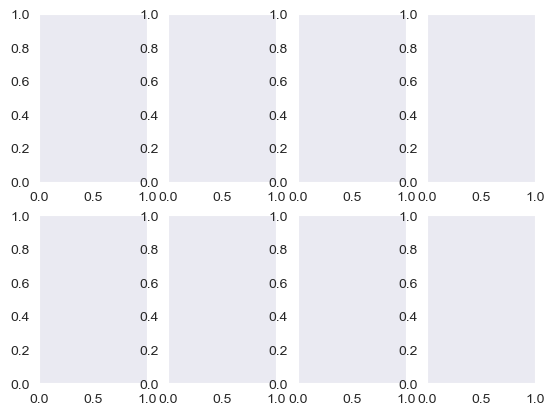

In [18]:
correlations3 = phishing_clean.corr()
fig, (ax1, ax2) = plt.subplots(2,4)
sns.heatmap(correlations, cmap="YlGnBu", annot=False, ax=ax1).set(title = 'Before')
sns.heatmap(correlations3, cmap="YlGnBu", annot=False, ax=ax2).set(title = 'After')
plt.show()

#### 2.2    Data Analysis

In [ ]:
phishing_clean.describe()

#### 2.3    Data Preprocessing

After downloading and importing the dataset, the first step was cleaning. The process began by removing highly descriptive features that would be useful for a tokenization project or a large language model (LLM) but useful for neural network projects. These features included *filename, URL, Domain, TLD, and Title*.  We also removed job_id since it provided no value to the algorithm.

During exploratory analysis,

With more than fifty features, we had to ensure that the dataset was properly scaled by standardizing, if possible, performing dimension reduction, applying regularization to reduce risks of overfitting and feature engineering.







#### 3      Methods

In this section, an overview of the methods and algorithms used in the phishing URL project.  First, the data was checked for missing values, data types, scaling features and observing the correlations between features. We evaluated the performance of three machine learning algorthims, including Neural Network, Random Forest using PCA, and logistic Regression. 

As a baseline, we observed the performance using the moderately imbalanced dataset compared to the balanced dataset. We trained the model on the training dataset and evaluated the performance on the testing data.


#### 3.1    Neural Network (NN)

A Neural Network is modeled after neurons in the human body. It consists of multiple interconnected neurons arranged in layers, working together to solve complex problems.  In the context of machine learning, a neuron consists of four components: inputs, the weighted sum of inputs, the application of an activation function to the weighted summation, and the resulting output.
<left><img src="https://live.staticflickr.com/65535/51633984258_9b95f324ce.jpg" width="300" height="150" alt="artifcal-neuron"><figcaption>Figure 4: Artificial Neuron Representation</figcaption></left>

As shown in Figure 4, the process begins with step 1, where the input 𝑥 is derived from the sample data. The next layer, known as the hidden layer, is the first computational layer of the network. This layer acts as a hyperparameter, allowing the model to be fine-tuned. The input is assigned to a weight and a bias, represented by 𝑧. During this layer, the activation function g(z) is applied.  For this study, we used Linear and Tanh activation functions to process the data effectively. Finally, the output layer receives the results from the activation function represented as a.  This values is either passed to the next layer as the next input or becomes the final results as y-hat.

In [ ]:
from sklearn.model_selection import train_test_split
def get_train_valid_test_data(
    X: np.ndarray, 
    y: np.ndarray, 
):
    """ Randomizes and then splits the data into train, validation, and test sets.

        Args:
            X: Data given as a 2D matrix

            y: Labels given as a vector 
    """
    assert isinstance(X, np.ndarray), f'`X` must be a NumPy array, got type {type(X)} instead.'
    assert isinstance(y, np.ndarray), f'`y` must be a NumPy array, got type {type(y)} instead.'
    X_trn, X_tst, y_trn, y_tst = train_test_split(X, y, train_size=.8, random_state=42)
    X_trn, X_vld, y_trn, y_vld = train_test_split(X_trn, y_trn, train_size=.8, random_state=42)

    return X_trn, y_trn, X_vld, y_vld, X_tst, y_tst

In [ ]:
# Standardization and Processing Data
from sklearn.preprocessing import StandardScaler

def get_preprocessed_data() -> Tuple[np.ndarray, ...]:
    """ Gets preprocessed data for training, validation, and testing

        Return:
            A tuple of NumPy arrays where indices 0-1 
            contain the training data/targets, indices 2-3
            contain the validation data/targets, and 4-5
            contain the testing data/targets.
    """

    # TODO 2.1 - 2.3
    # Drop the label column and store the features (pixel values) in X
    X = phishing_clean.drop('label', axis=1).values
    y = phishing_clean['label'].values

    X_trn, y_trn, X_vld, y_vld, X_tst, y_tst = get_train_valid_test_data(X, y)

    #standardize
    stand = StandardScaler()
    stand.fit(X_trn)  #compute the mean and std

    X_trn = stand.fit_transform(X_trn)  #standardizes 
  
    X_tst = stand.transform(X_tst)

    X_vld = stand.transform(X_vld)

    return X_trn, y_trn.reshape(-1, 1), X_vld, y_vld.reshape(-1, 1), X_tst, y_tst.reshape(-1, 1)

In [ ]:
# LInear Activation Funtion

class Linear():
    """ The linear or identity actionvation function """
    @staticmethod
    def activation(z: np.ndarray) -> np.ndarray:
        """ Computes the output of the linear activation function """
        # TODO 3.1

        return z
        
    
    @staticmethod
    def derivative(z: np.ndarray) -> np.ndarray:
        """ Computes the derivative for the linear activation function """
        # TODO 3.2

        return np.ones(z.shape)

In [ ]:
# Tanh activation function

class Tanh():
    """ The tanh actionvation function """
    @staticmethod
    def activation(z: np.ndarray) -> np.ndarray:
        """ Computes the output of the tanh activation function """
        # TODO 4.1

        return np.tanh(z)

    @staticmethod
    def derivative(z: np.ndarray) -> np.ndarray:
        """ Computes the derivative of the tanh activation function """
        # TODO 4.2

        return 1 - np.tanh(z)**2  

In [ ]:
# Apply Initial Weights to Features

def init_weights(
    m_input_features: int, 
    hidden_neurons: int, 
    output_neurons: int, 
) -> Tuple[np.ndarray, ...]:
    """ Initilize the hidden and output layer parameters
        
        Args:
            m_input_features: The number of input features

            hidden_neurons: The number of hidden neurons or units to 
                use in the hidden layer.

            output_neurons: The number of output neurons to use in 
                the output layer.

        Returns:
            A tuple of NumPy arrays containing the weights and biases
            for the hidden and output layers.
    """
    # TODO 5
    # https://numpy.org/doc/stable/reference/random/generated/numpy.random.uniform.html

    W1 =  np.random.uniform(low=-0.5, high=0.5, size=(m_input_features, hidden_neurons))
    #b1 = np.ones((1, hidden_neurons)).reshape(1,-1)
    b1 = np.ones([1, hidden_neurons]).reshape(1,-1)
    W2 = np.random.uniform(low=-0.5, high=0.5, size=(hidden_neurons, output_neurons))
    #b2 = np.ones((1, output_neurons)).reshape(1,-1)
    b2 = np.ones([1, output_neurons]).reshape(1,-1)

    assert W1.shape == (m_input_features, hidden_neurons), "W1 shape mismatch!"
    assert b1.shape == (1, hidden_neurons), "b1 shape mismatch!"
    assert W2.shape == (hidden_neurons, output_neurons), "W2 shape mismatch!"
    assert b2.shape == (1, output_neurons), "b2 shape mismatch!"

    
    return W1, b1, W2, b2

In [ ]:
# Forward Pass
def forward(
    X: np.ndarray, 
    W1: np.ndarray, 
    b1: np.ndarray,
    W2: np.ndarray, 
    b2: np.ndarray, 
) -> Tuple[np.ndarray, ...]:
    """ Forward pass for 2 layer neural network
    
        Args:
            X: Input features
            
            W1: Hidden layer weights 
            
            b1: Hidden layer baises

            W2: Output layer weights 
            
            b2: Output layer baises

        Returns:
            A tuple of NumPy arrays containing the linear combination and 
            acitvation outputs for each layer. These are needed to compute 
            the backward pass.
    """

    # TODO 6
    
    Z1 = X @ W1 + b1                                                                                 #.reshape(1,-1)   ADDED .reshape(1,-1)
    A1 = Tanh.activation(Z1)  #usage in TEST.linear
    Z2 = A1 @ W2 + b2                                                                                #.reshape(1,-1);  comeback and remove .reshape(1,-1) and reTEST
    A2 = Linear.activation(Z2)

    return Z1, A1, Z2, A2

In [ ]:
# Backward
def output_layer_grads(
    X: np.ndarray,
    y: np.ndarray,
    W1: np.ndarray,
    Z1: np.ndarray,
    A1: np.ndarray,
    W2: np.ndarray,
    Z2: np.ndarray,
    A2: np.ndarray
) -> Tuple[np.ndarray, np.ndarray]:
    """ Compute gradients for the output layer parameters
        
        Note:
            You might not use all the passed arguments!
    
        Args:
            X: Input data given as a matrix
            
            y: Ground truth labels given as a column vector

            W1: Hidden layer weights
            
            Z1: Linear combination output for hidden layer

            A1: Activation output for hidden layer
            
            W2: Output layer weights

            Z2: Linear combination output for the output layer

            A2: Activation output or the output layer. Also 
                referred to as y_hat.
            
        Return:
            A tuple of NumPy arrays containing the average gradient 
            for the output layer weights and biases.
    """
    # TODO 7

    #W2_avg_grad = (A1.T @ (A2 - y)) / y.shape[0]
    #b2_avg_grad = (A2 - y).mean(axis = 0).reshape(1, 1)
    
    # code reused from note-neural-network provided by professor
    def delta_mse(y, y_hat):
        return y_hat - y
            
    y_hat = A2
    delta_mse_A2 = delta_mse(y, y_hat)
    delta_A2_Z2 = Linear.derivative(Z2)
    #delta_Z2_b2 = np.ones([len(y), 1])
    delta_Z2_b2 = np.ones([y.shape[0], 1])
    delta_Z2_W2 = A1

    delta_mse_Z2 = delta_mse_A2 * delta_A2_Z2
    #print(f"{delta_mse_Z2.shape} = {delta_mse_A2.shape} * {delta_A2_Z2.shape}")

    delta_mse_W2 = delta_Z2_W2.T  @ delta_mse_Z2 
    #print(f"{delta_mse_W2.shape} = {delta_Z2_W2.T.shape} @ {delta_mse_Z2.shape}")

    # Average Gradient
    #W2_avg_grad = delta_mse_W2 / len(y) 
    W2_avg_grad = delta_mse_W2 / y.shape[0] 
    

    # Gradient
    delta_mse_Z2 = delta_mse_A2 * delta_A2_Z2
    #print(f"{delta_mse_Z2.shape} = {delta_mse_A2.shape} * {delta_A2_Z2.shape}")
    
    delta_mse_b2 = delta_Z2_b2.T @  delta_mse_Z2
    #print(f"{delta_mse_b2.shape} = {delta_Z2_b2.T.shape} @ {delta_mse_Z2.shape}")
    
    # Average Gradient
    b2_avg_grad = delta_mse_b2 / len(y) 
    
    return W2_avg_grad, b2_avg_grad

In [ ]:
# Hidden Layer

def hidden_layer_grads(
    X: np.ndarray,
    y: np.ndarray,
    W1: np.ndarray,
    Z1: np.ndarray,
    A1: np.ndarray,
    W2: np.ndarray,
    Z2: np.ndarray,
    A2: np.ndarray
) -> Tuple[np.ndarray, np.ndarray]:
    """ Compute gradients for the hidden layer parameters
        
        Note:
            You might not use all the passed arguments!
    
        Args:
            X: Input data given as a matrix
            
            y: Ground truth labels given as a column vector

            W1: Hidden layer weights
            
            Z1: Linear combination output for hidden layer

            A1: Activation output for hidden layer
            
            W2: Output layer weights

            Z2: Linear combination output for the output layer

            A2: Activation output or the output layer. Also 
                referred to as y_hat.
            
        Return:
            A tuple of NumPy arrays containing the average gradient 
            for the hidden layer weights and biases.
    """
    # TODO 8
    #W1_avg_grad = (X.T @ (A2 - y) @ W2.T @ (1- Tanh.activation(Z1))) / len(X)
    #b1_avg_grad = ((A2 - y) @ W2.T @ (1- Tanh.activation(Z1))).mean(axis =0)  does pass Test but used professor's code from example

    # code reused from note-neural-network provided by professor
    y_hat = A2

    #def delta_mse(y, y_hat):
    #   return y_hat - y   delta_mse(y, y_hat)

    delta_mse_A2 = y_hat - y
    delta_A2_Z2 = Linear.derivative(Z2)
    delta_Z2_A1 = W2
    delta_A1_Z1 = Tanh.derivative(Z1)
    delta_Z1_W1 = X

    delta_mse_A1 = (delta_mse_A2 * delta_A2_Z2) @ delta_Z2_A1.T
    #print(f"{delta_mse_A1.shape} =  {delta_mse_A2.shape} * {delta_A2_Z2.shape} @ {delta_Z2_A1.T.shape}")

    delta_mse_W1 = delta_Z1_W1.T @ ( delta_mse_A1 * delta_A1_Z1 )
    #print(f"{delta_mse_W1.shape} = {delta_Z1_W1.T.shape} @ ({delta_mse_A1.shape} * {delta_A1_Z1.shape})")

    W1_avg_grad = delta_mse_W1 / y.shape[0]

    delta_Z1_b1 = np.ones([y.shape[0], 1])

    delta_mse_b1 =  delta_Z1_b1.T @ (delta_mse_A1 * delta_A1_Z1)
    #print(f"{delta_mse_b1.shape} = {delta_Z1_b1.T.shape} @ ({delta_mse_A1.shape} * {delta_A1_Z1.shape})")

    b1_avg_grad = delta_mse_b1 / y.shape[0]
    
    return W1_avg_grad, b1_avg_grad

In [ ]:
# Create batches

def get_batches(
    data_len: int, 
    batch_size: int = 32,
) -> List[np.ndarray]:
    """ Generates mini-batches based on the data indexes
        
        Args:
            data_len: Length of the data or number of data samples 
                in the data. This is used to generate the indices of
                the data.
            
            batch_size: Size of each mini-batch where the last mini-batch
                might be smaller than the rest if the batch_size does not 
                evenly divide the data length.

        Returns:
            A list of NumPy array's holding the indices of batches
    """
    indices = np.arange(data_len)
    np.random.shuffle(indices)
    batches = [indices[i:i+batch_size] for i in range(0, data_len, batch_size)]

    return batches

In [ ]:
# Neural Network with all samples
class NeuralNetwork():
    def __init__(self,
        hidden_neurons: int,
        output_neurons: int,
        alpha: float, 
        batch_size: int,
        epochs: int = 1,
        seed: int = 0,
    ):
        """ A two layer neural network using SGD
            
            Attributes:
                hidden_neurons: Number of hidden units/neurons.
                
                output_neurons: Number of output neuorns
                
                alpha: learning rate or step size.
                
                batch_size: Size of mini-batches for mini-batch gradient
                    descent.
                
                epochs: Number of epochs to run for mini-batch
                    gradient descent.
                    
                seed: Seed to be used for NumPy's np.random.seed() function.
    
                W1: Hidden layer weights with shape (inputs, neurons)
                
                b1: Hidden layer baises with shape (1, neurons)
                
                W2: Output layer weights with shape (inputs, neurons)
                
                b2: Output layer baises with shape (1, neurons)
    
                trn_error: Stores the training error for each epoch.
    
                vld_error: Stores the validation error for each epoch.
        """
        self.hidden_neurons = hidden_neurons
        self.output_neurons = output_neurons
        self.batch_size = batch_size
        self.alpha = alpha
        self.epochs = epochs
        self.seed = seed
        
        self.W1, self.b1 = None, None
        self.W2, self.b2 = None, None
        self.trn_error = None
        self.vld_error = None

    def fit(
        self,
        X: np.ndarray, 
        y: np.ndarray,
        X_vld: np.ndarray = None, 
        y_vld:np.ndarray = None,
    ): 
        """ Trains a basic two layer neural network using SGD
        
            Args:
                X: Training data given as a 2D matrix

                y: Training labels given as a 2D column vector

                X_vld: Validation data given as a 2D matrix. Used 
                    to compute the validation RMSE for each epoch.

                y_vld: Validation labels given as a 2D matrix. Used 
                    to compute the validation RMSE for each epoch.
                
            Returns:
                The class's own object reference. 
        """
        np.random.seed(self.seed)
        self.trn_error = []
        self.vld_error = []
        
        # TODO 9.1 - 9.2
        self.W1, self.b1, self.W2, self.b2 = init_weights(X.shape[1], self.hidden_neurons,  self.output_neurons)
        
        for e in range(self.epochs):
            batches = []

            batches = get_batches(len(X),self.batch_size)

            for b in batches:

                Z1, A1, Z2, A2 = forward(X=X[b], W1=self.W1, b1=self.b1, W2=self.W2, b2=self.b2)

                #print("Output Layer")
                W2_avg_grad, b2_avg_grad = output_layer_grads(X[b], y[b], self.W1, Z1, A1, self.W2, Z2, A2)

                #print("hidden layer")
                W1_avg_grad, b1_avg_grad = hidden_layer_grads(X[b], y[b], self.W1, Z1, A1, self.W2, Z2, A2)


                self.W2 -= self.alpha * W2_avg_grad
                self.b2 -= self.alpha * b2_avg_grad
                
                self.W1 -= self.alpha * W1_avg_grad
                self.b1 -= self.alpha * b1_avg_grad  


            trn_preds = self.predict(X)
            trn_error = rmse(y, trn_preds)
            self.trn_error.append(trn_error)

            if X_vld is not None and y_vld is not None:
                vld_preds = self.predict(X_vld)
                vld_error = rmse(y_vld, vld_preds)
                self.vld_error.append(vld_error)
        
        return self
    
    def predict(self, X: np.ndarray):
        """ Make predictions using forward pass.

            Args:
                X: Testing data given as a 2D matrix

            Returns:
                A 2D column vector of predictions for each data sample in X
        """
        # TODO 9.3
        Z1, A1, Z2, A2 = forward(X=X, W1=self.W1, b1=self.b1, W2=self.W2, b2=self.b2)
        return  A2

In [ ]:
# Training Results for Neural Network

X_trn, y_trn, X_vld, y_vld, X_tst, y_tst = get_preprocessed_data()

nn = NeuralNetwork(
    hidden_neurons=29,
    output_neurons=1,
    batch_size=61,
    alpha=0.06,
    epochs=200, #100
    seed=0,
    )

nn.fit(X_trn, y_trn, X_vld=X_vld, y_vld=y_vld)
y_hat_trn = nn.predict(X_trn)
trn_mse_score = mse(y_trn, y_hat_trn)
print(f"Train MSE: {trn_mse_score}")
trn_rmse_score = rmse(y_trn, nn.predict(X_trn))
print(f"Train RMSE: {trn_rmse_score}")            


y_hat_vld = nn.predict(X_vld)
vld_mse_score = mse(y_vld, y_hat_vld)
print(f"Validation MSE: {vld_mse_score}")
trn_rmse_score = rmse(y_vld, nn.predict(X_vld))
print(f"Validation RMSE: {trn_rmse_score}")   

y_hat_tst = nn.predict(X_tst)
tst_mse_score = mse(y_tst, y_hat_tst)
print(f"Test MSE: {tst_mse_score}")
trn_rmse_score = rmse(y_tst, nn.predict(X_tst))
print(f"Test RMSE: {trn_rmse_score}")   

plt.plot(nn.trn_error, label='Train ')
plt.plot(nn.vld_error, label='Validation ')
plt.title("Learning Curve")
plt.ylabel("RMSE")
plt.xlabel("Epoch")
plt.legend()
plt.show()

In [ ]:
# Standardization and Processing Data
from sklearn.preprocessing import StandardScaler

def get_preprocessed_data1() -> Tuple[np.ndarray, ...]:
    """ Gets preprocessed data for training, validation, and testing

        Return:
            A tuple of NumPy arrays where indices 0-1 
            contain the training data/targets, indices 2-3
            contain the validation data/targets, and 4-5
            contain the testing data/targets.
    """

    # TODO 2.1 - 2.3
    # Drop the label column and store the features (pixel values) in X
    X = resampled_df.drop('label', axis=1).values
    y = resampled_df['label'].values

    X_trn, y_trn, X_vld, y_vld, X_tst, y_tst = get_train_valid_test_data(X, y)

    #standardize
    stand = StandardScaler()
    stand.fit(X_trn)  #compute the mean and std

    X_trn = stand.fit_transform(X_trn)  #standardizes 
  
    X_tst = stand.transform(X_tst)

    X_vld = stand.transform(X_vld)

    return X_trn, y_trn.reshape(-1, 1), X_vld, y_vld.reshape(-1, 1), X_tst, y_tst.reshape(-1, 1)

In [ ]:
# neural Network with resampled data

X_trn, y_trn, X_vld, y_vld, X_tst, y_tst = get_preprocessed_data1()

nn = NeuralNetwork(
    hidden_neurons=29,
    output_neurons=1,
    batch_size=61,
    alpha=0.06,
    epochs=200, #100
    seed=0,
    )

nn.fit(X_trn, y_trn, X_vld=X_vld, y_vld=y_vld)
y_hat_trn = nn.predict(X_trn)
trn_mse_score = mse(y_trn, y_hat_trn)
print(f"Train MSE: {trn_mse_score}")
trn_rmse_score = rmse(y_trn, nn.predict(X_trn))
print(f"Train RMSE: {trn_rmse_score}")            


y_hat_vld = nn.predict(X_vld)
vld_mse_score = mse(y_vld, y_hat_vld)
print(f"Validation MSE: {vld_mse_score}")
trn_rmse_score = rmse(y_vld, nn.predict(X_vld))
print(f"Validation RMSE: {trn_rmse_score}")   

y_hat_tst = nn.predict(X_tst)
tst_mse_score = mse(y_tst, y_hat_tst)
print(f"Test MSE: {tst_mse_score}")
trn_rmse_score = rmse(y_tst, nn.predict(X_tst))
print(f"Test RMSE: {trn_rmse_score}")   

plt.plot(nn.trn_error, label='Train ')
plt.plot(nn.vld_error, label='Validation ')
plt.title("Learning Curve")
plt.ylabel("RMSE")
plt.xlabel("Epoch")
plt.legend()
plt.show()

#### 3.2    PCA

In [ ]:
# https://scikit-learn.org/stable/modules/generated/sklearn.decomposition.PCA.html

from sklearn.decomposition import PCA

X = phishing_clean.drop('label', axis=1).values
y = phishing_clean['label'].values

pca = PCA(n_components = 10)
X2D = pca.fit_transform(X)

print(pca.explained_variance_ratio_)  # results indicate that the 1st PC contains 99.9% of the dataset's variance



#### 3.2    Random Forest

Random Forest is an ensemble algorithm that utilizes multiple decision trees to make predictions. In our study, we use Random Forest to determine whether a URL is legitimate or not.

In a Random Forest model, each decision tree is trained on a randomly selected subset of the training data. The final prediction is generated through majority voting among the decision trees. Additionally, Random Forest selects the best features from a random subset of available features, resulting in greater diversity among the trees and improving model performance.

Furthermore, this method makes it easier to determine feature importance by analyzing how frequently nodes utilize specific features across all trees in the forest (O'Reilly).

In [ ]:
from sklearn.ensemble import RandomForestClassifier

X = phishing_clean.drop('label', axis=1).values
y = phishing_clean['label'].values
X_trn, y_trn, X_vld, y_vld, X_tst, y_tst = get_preprocessed_data()


rf = RandomForestClassifier()
rf.fit(X_trn, y_trn)

accuracy = rf.score(X_tst, y_tst)

results_df = pd.DataFrame({
    "Variance Retained": [0.95], 
    "Accuracy": [accuracy]
})

print(results_df)


#### 3.3    Random Forest wih PCA

In [ ]:
# https://builtin.com/machine-learning/pca-in-python
# https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.RandomForestClassifier.html
'''
from sklearn.decomposition import PCA

X = phishing_clean.drop('label', axis=1).values
y = phishing_clean['label'].values
X_trn, y_trn, X_vld, y_vld, X_tst, y_tst = get_preprocessed_data()

pca = PCA(.90)
pca.fit(X_trn)
num_components = pca.n_features_in_

X_trn = pca.transform(X_trn)
X_tst = pca.transform(X_tst)

from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier()
rf.fit(X_trn, y_trn)

accuracy = rf.score(X_tst, y_tst)

results_df = pd.DataFrame({
    "Variance Retained": [0.95], 
    "Number of Components": [num_components],
    "Accuracy": [accuracy]
})

print(results_df)
'''

#### 3.3    XBOOST

In [ ]:
import xgboost as xgb
from sklearn.metrics import accuracy_score

X = phishing_clean.drop('label', axis=1).values
y = phishing_clean['label'].values
X_trn, y_trn, X_vld, y_vld, X_tst, y_tst = get_preprocessed_data()

# Train XGBoost model
model = xgb.XGBClassifier(n_estimators=100, max_depth=5, learning_rate=0.1, random_state=42)
model.fit(X_trn, y_trn)

y_pred = model.predict(X_tst)

accuracy = accuracy_score(y_tst, y_pred)
print(f'Model Accuracy: {accuracy:.4f}')


#### 3.4    Cross Validation

In [19]:
# https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.cross_validate.html
# https://scikit-learn.org/stable/modules/cross_validation.html

from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import make_scorer, accuracy_score, precision_score, recall_score, f1_score


X = phishing_clean.drop('label', axis=1).values
y = phishing_clean['label'].values

# Define models
models = {
    "Random Forest": RandomForestClassifier(),
    "XGBoost": XGBClassifier(),
    "Neural Network": MLPClassifier()
}

# Define scoring metrics
scoring = {
    "accuracy": make_scorer(accuracy_score),
    "precision": make_scorer(precision_score, average='macro'),
    "recall": make_scorer(recall_score, average='macro'),
    "f1": make_scorer(f1_score, average='macro')
}

# Perform cross-validation
kf = StratifiedKFold(n_splits=5)

for name, model in models.items():
    print(f"\n{name} Results:")
    for metric, scorer in scoring.items():
        scores = cross_val_score(model, X, y, cv=kf, scoring=scorer)
        print(f"{metric}: {scores.mean():.4f}")




Random Forest Results:
accuracy: 1.0000
precision: 1.0000
recall: 1.0000
f1: 1.0000

XGBoost Results:
accuracy: 1.0000
precision: 1.0000
recall: 1.0000
f1: 1.0000

Neural Network Results:
accuracy: 0.9994
precision: 0.9952
recall: 0.9992
f1: 0.9987


#### 4      Results

#### 4.1    Experimental Setup      


#### 4.2    Observations


#### 4.3    Anlaysis


#### 4.4    Experiments to Support Analysis   

#### 5      Conclusions

Provide concluding remarks about the project (1-2 paragraphs)

Can discuss the following:
-Thoughts about the project
-What you have learned
-Challenges and how you overcome them

#### References and Citations    Use MLA style to cite and reference others work! using MLA 8th edition

Galarnyk, Michael. "PCA Using Python: A Tutorial Principal component analysis (PCA) in Python can be used to speed up model training or for data visualization. This tutorial covers both using scikit-learn." builtin, 2024, https://builtin.com/machine-learning/pca-in-python

Prasad, Arvind and Shalini Chandra. "PhiUSIIL Phishing URL (Website)." UCI Machine Learning Repository, 2024, https://doi.org/10.1016/j.cose.2023.103545.

Arvind Prasad, Shalini Chandra,hiUSIIL: A diverse security profile empowered phishing URL detection framework based on similarity index and incremental learning, Computers & Security, Volume 136, 2024, 103545, ISSN 0167-4048, https://doi.org/10.1016/j.cose.2023.103545. (https://www.sciencedirect.com/science/article/pii/S0167404823004558)

Violino, Bob. "Phishing attacks are increasing and getting more sophisticated. Here’s how to avoid them." CNBC, 2023, https://www.cnbc.com/2023/01/07/phishing-attacks-are-increasing-and-getting-more-sophisticated.html?




Hands-On Machine Learning with Scikit-Learn, Keras, and TensorFlow, 3rd Edition
by Aurélien Géron
Released October 2022
Publisher(s): O'Reilly Media, Inc.
ISBN: 9781098125974

#### AI Assistance
After running Neural Netowrk with all features, I ran the results into CoPilot.  
`Me: ` completed run of neural network model with 225000 obs and 50 features. results
Train MSE: 0.00011060664595859682
Train RMSE: 0.010516969428433118
Validation MSE: 0.00011637581270834293
Validation RMSE: 0.010787762173330618
Test MSE: 0.00010521815551091002
Test RMSE: 0.010257590141495711

`CoPilot: ` Your model seems to be performing well, with relatively low error values across the training, validation, and test sets. The MSE and RMSE values indicate that your predictions are quite close to the actual values.

A few things to consider:

The validation error is slightly higher than the training error, but not alarmingly so—this suggests a good generalization.

The test MSE is lower than both the training and validation MSE, which might indicate strong generalization on unseen data.

The differences between training and validation RMSE are small, suggesting that overfitting may not be a major concern.


## Acknowledgement

In [ ]:
# Link to Source Code 